In [ ]:
#REAL TRAINED WEIGHTS OR DATASET WILL NOT BE DISCLOSED.
#ONLY TRAINING SCRIPT TO PROVE I TRAINED.

In [9]:
import torch, sys, os
import ultralytics
from ultralytics import YOLO

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Ultralytics: 8.3.192
PyTorch: 2.7.1+cu118
CUDA available: True


In [14]:
from ultralytics import YOLO
import torch, os

DATA_YAML = r"C:\Users\shrit\Downloads\out_yolo\dataset.yaml"
device = 0 if torch.cuda.is_available() else "cpu"

model = YOLO("yolo11n.pt")

RESULTS = model.train(
    data=DATA_YAML,
    imgsz=640,          
    epochs=50,
    batch=16,
    device=device,
    pretrained=True,
    patience=10,
    cos_lr=True,
    amp=True,
    mosaic=1.0,
    project=r"C:\Users\shrit\Downloads\yolo_runs",
    name="bdd11n-960-2",
    plots=True,
)
print("Run:", RESULTS.save_dir, "\nBest:", RESULTS.best)


Ultralytics 8.3.192  Python-3.10.18 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16380MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\shrit\Downloads\out_yolo\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=bdd11n-960-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0

AttributeError: 'DetMetrics' object has no attribute 'best'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

    Attributes:
        names (Dict[int, str]): A dictionary of class names.
        box (Metric): An instance of the Metric class for storing detection results.
        speed (Dict[str, float]): A dictionary for storing execution times of different parts of the detection process.
        task (str): The task type, set to 'detect'.
        stats (Dict[str, List]): A dictionary containing lists for true positives, confidence scores, predicted classes, target classes, and target images.
        nt_per_class: Number of targets per class.
        nt_per_image: Number of targets per image.

    Methods:
        update_stats: Update statistics by appending new values to existing stat collections.
        process: Process predicted results for object detection and update metrics.
        clear_


image 1/1 C:\Users\shrit\Desktop\CAC-PROJECT\ml_models\example2.webp: 448x640 1 bike, 2 cars, 1 rider, 1 traffic sign, 50.5ms
Speed: 1.9ms preprocess, 50.5ms inference, 63.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs\detect\predict3


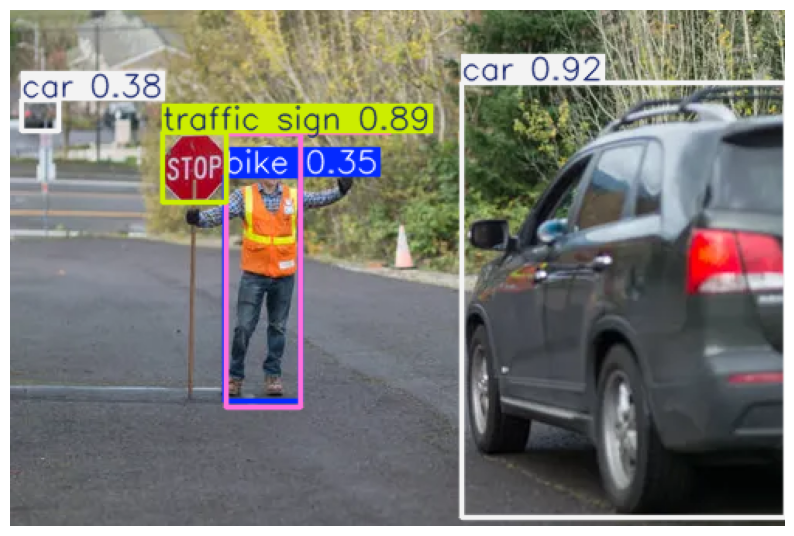

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO(r"C:\Users\shrit\Downloads\yolo_runs\bdd11n-960-2\weights\best.pt")

results = model(r"C:\Users\shrit\Desktop\CAC-PROJECT\ml_models\example2.webp", save=True, conf=0.25)

for r in results:
    im_array = r.plot()

    im_rgb = im_array[:, :, ::-1]

    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis("off")
    plt.show()

In [ ]:
import tensorflow as tf
import os

saved_model_dir = r"C:\Users\shrit\Desktop\CAC-PROJECT\best_tf"
out_path = os.path.join(saved_model_dir, "best_float32_clean.tflite")

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
converter.optimizations = []
converter._experimental_lower_tensor_list_ops = True  # force canonical lowering

tflite_model = converter.convert()
open(out_path, "wb").write(tflite_model)
print("Wrote:", out_path)

# Sanity check first ops
interp = tf.lite.Interpreter(model_path=out_path)
interp.allocate_tensors()
for d in interp._get_ops_details()[:10]:
    print(d["index"], d["op_name"])

[INFO] Total ops: 370
[PAD FOUND] {'index': 0, 'op_name': 'PAD', 'inputs': array([  0, 221]), 'outputs': array([222])}
[PAD FOUND] {'index': 4, 'op_name': 'PAD', 'inputs': array([225, 221]), 'outputs': array([226])}
[PAD FOUND] {'index': 24, 'op_name': 'PAD', 'inputs': array([245, 221]), 'outputs': array([246])}
[PAD FOUND] {'index': 44, 'op_name': 'PAD', 'inputs': array([265, 221]), 'outputs': array([266])}
[PAD FOUND] {'index': 81, 'op_name': 'PAD', 'inputs': array([302, 221]), 'outputs': array([303])}
[PAD FOUND] {'index': 231, 'op_name': 'PAD', 'inputs': array([444, 221]), 'outputs': array([458])}
[PAD FOUND] {'index': 265, 'op_name': 'PAD', 'inputs': array([478, 221]), 'outputs': array([492])}


In [14]:
import tensorflow as tf

tflite_path = r"C:\Users\shrit\Downloads\yolo_runs\bdd11n-960-2\weights\best_saved_model\best_float32.tflite"

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

ops = interpreter._get_ops_details()
print("[INFO] Total ops:", len(ops))
has_pad = False
for d in ops:
    if d["op_name"] == "PAD":
        print("[PAD FOUND]", d)
        has_pad = True
if not has_pad:
    print("✅ No PAD ops — this model is clean!")

[INFO] Total ops: 370
[PAD FOUND] {'index': 0, 'op_name': 'PAD', 'inputs': array([  0, 221]), 'outputs': array([222])}
[PAD FOUND] {'index': 4, 'op_name': 'PAD', 'inputs': array([225, 221]), 'outputs': array([226])}
[PAD FOUND] {'index': 24, 'op_name': 'PAD', 'inputs': array([245, 221]), 'outputs': array([246])}
[PAD FOUND] {'index': 44, 'op_name': 'PAD', 'inputs': array([265, 221]), 'outputs': array([266])}
[PAD FOUND] {'index': 81, 'op_name': 'PAD', 'inputs': array([302, 221]), 'outputs': array([303])}
[PAD FOUND] {'index': 231, 'op_name': 'PAD', 'inputs': array([444, 221]), 'outputs': array([458])}
[PAD FOUND] {'index': 265, 'op_name': 'PAD', 'inputs': array([478, 221]), 'outputs': array([492])}
